In [5]:
import yfinance as yf
import pandas as pd 
from datetime import datetime, timedelta
import numpy as np 
from scipy.optimize import minimize
from fredapi import Fred
import matplotlib.pyplot as plt
import os


In [6]:
tickers = ['URTH','BND','TTE','QQQ','EEM']
years = 13
end_date = datetime.today()
start_date = end_date - timedelta(days = years * 365)

adj_close_df = pd.DataFrame()
for ticker in tickers : 
    data = yf.download(ticker, start = start_date, end = end_date, auto_adjust = False)
    adj_close_df[ticker] = data['Adj Close']

print(adj_close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  URTH        BND        TTE         QQQ        EEM
Date                                                               
2013-09-30   52.242310  55.416050  27.941586   71.066055  30.774155
2013-10-01   51.849445  55.348793  28.042902   71.786789  31.385706
2013-10-02   51.385880  55.410580  28.163492   71.759781  31.506512
2013-10-03   50.938019  55.438061  27.907814   70.921913  31.385706
2013-10-04   51.181580  55.376270  28.081488   71.534508  31.793409
...                ...        ...        ...         ...        ...
2026-09-21  209.699997  71.400002  90.059998  741.469971  68.830002
2026-09-22  210.020004  71.410004  89.849998  747.460022  69.099998
2026-09-23  207.839996  70.809998  91.669998  741.210022  67.709999
2026-09-24  207.649994  70.449997  91.889999  741.099976  67.250000
2026-09-25  208.960007  70.569702  90.779999  744.969971  68.044998

[3267 rows x 5 columns]


In [7]:
fred = Fred(api_key='35ab422cdfc771dc186795835f1a301d')
three_month_TB = fred.get_series_latest_release('DTB3')/100
rff = three_month_TB.iloc[-1]

Optimal Weights:
URTH: 0.0000
BND: 0.1597
TTE: 0.0403
QQQ: 0.8000
EEM: 0.0000
Expected Annual Return: 0.1517
Expected Volatility: 0.1758
Sharpe Ratio: 0.6332


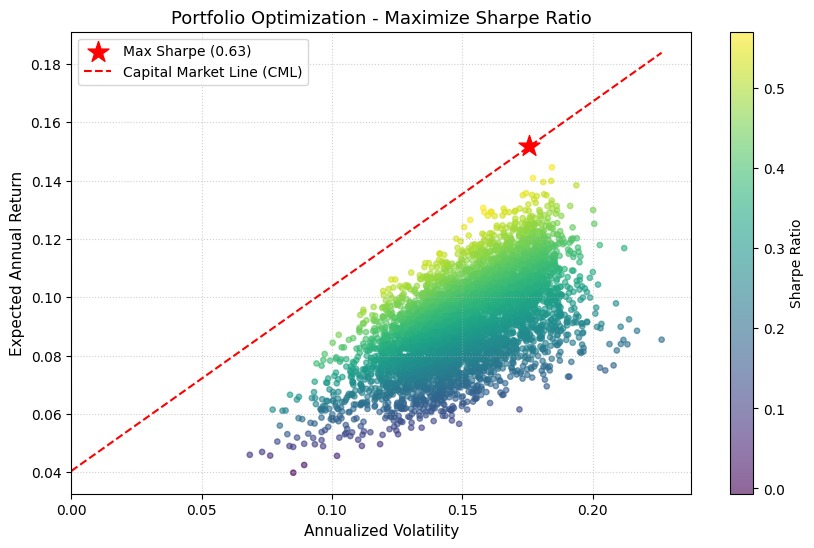

In [8]:
#returns and logarithmic returns
returns = adj_close_df/adj_close_df.shift(1) 
log_returns = np.log(returns).dropna()

cov_matrix = log_returns.cov()*252

#Volatility, Expected Returns and Sharpe Ratio functions

def std (weights, cov_matrix):
    var = weights.T @ cov_matrix @ weights
    return np.sqrt(var)

def exp_returns (weights, log_returns) :
    return np.sum(log_returns.mean()*weights)*252

def SharpeR (weights, log_returns, cov_matrix, rff) : 
    return (exp_returns(weights, log_returns) - rff) / std(weights, cov_matrix)

def neg_SharpeR(weights, log_returns, cov_matrix, rff):
    return -SharpeR(weights, log_returns, cov_matrix, rff)

#Constraints and Bounds, we can play with bounds to see the effect on the Sharpe Ratio and the allocation
constraints = ({'type' : 'eq', 'fun' : lambda w: np.sum(w) - 1})
bounds = [(0, 0.8) for _ in range(len(tickers))]
initial_weights = np.array([1/len(tickers)]*len(tickers))
#Maximization of the Sharpe Ratio witj a Minimization of the negative Sharpe Ratio 
results = minimize(
    neg_SharpeR,
    initial_weights,
    args=(log_returns, cov_matrix, rff),
    method='SLSQP',  # Sequential Least Squares Programming
    bounds=bounds,
    constraints=constraints
)

optimized_weights = results.x
print("Optimal Weights:")
for ticker, weight in zip(tickers, optimized_weights):
    print(f"{ticker}: {weight:.4f}")

optimized_portfolio_return = exp_returns(optimized_weights, log_returns)
optimized_portfolio_std = std(optimized_weights, cov_matrix)
optimized_portfolio_SharpeR = SharpeR(optimized_weights,log_returns,cov_matrix,rff)
print(f"Expected Annual Return: {optimized_portfolio_return:.4f}")
print(f"Expected Volatility: {optimized_portfolio_std:.4f}")
print(f"Sharpe Ratio: {optimized_portfolio_SharpeR:.4f}")

# Monte Carlo simulation for 5000 portfolio
num_portfolios = 5000
n_assets = len(tickers)

# Volatility, Returns and Sharpe matrixes
sim_vol = np.zeros(num_portfolios)
sim_ret = np.zeros(num_portfolios)
sim_sharpe = np.zeros(num_portfolios)

for i in range(num_portfolios):
    while True:
        w = np.random.uniform(0, 0.8, n_assets)
        w /= np.sum(w)
        if np.all(w <= 0.8):
            break
    sim_ret[i] = exp_returns(w, log_returns)
    sim_vol[i] = std(w, cov_matrix)
    sim_sharpe[i] = SharpeR(w, log_returns, cov_matrix, rff)

#Graphic Representation
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    sim_vol, 
    sim_ret, 
    c=sim_sharpe, 
    cmap='viridis', 
    alpha=0.6, 
    s=15
)
plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(
    optimized_portfolio_std, 
    optimized_portfolio_return, 
    color='red', 
    marker='*', 
    s=250, 
    zorder=5,
    label=f'Max Sharpe ({optimized_portfolio_SharpeR:.2f})'
)

# CML (Capital Market Line)
max_vol = max(sim_vol)
cml_x = np.linspace(0, max_vol, 100)
cml_y = rff + optimized_portfolio_SharpeR * cml_x

plt.plot(
    cml_x, 
    cml_y, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label='Capital Market Line (CML)'
)

plt.title('Portfolio Optimization - Maximize Sharpe Ratio', fontsize=13)
plt.xlabel('Annualized Volatility', fontsize=11)
plt.ylabel('Expected Annual Return', fontsize=11)
plt.xlim(left=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.show()
